# Hybrid RAG (Hybrid Retrieval-Augmented Generation)

## Hybrid RAG란?

**Hybrid RAG**는 여러 검색 방식을 결합하여 더 정확하고 포괄적인 정보 검색을 수행하는 RAG 시스템입니다.

### Hybrid RAG의 핵심 개념

1. **다양한 검색 방식의 결합**
   - **Vector Search (의미 기반 검색)**: 임베딩 벡터를 사용한 의미적 유사도 검색
   - **Graph Search (구조 기반 검색)**: 그래프 데이터베이스(Neo4j)를 활용한 관계 기반 검색
   - **Keyword Search (키워드 검색)**: BM25 알고리즘을 사용한 키워드 매칭 검색

2. **Supervisor 패턴**
   - 사용자 질문을 분석하여 최적의 검색 전략을 자동으로 선택
   - 질문의 특성에 따라 적절한 검색 방식을 라우팅

3. **결과 통합 및 재순위화**
   - 여러 검색 결과를 통합
   - 점수 정규화를 통한 공정한 비교
   - LLM을 활용한 관련성 평가 및 재순위화

### Hybrid RAG의 장점

- **정확도 향상**: 여러 검색 방식의 장점을 결합하여 더 정확한 결과 제공
- **컨텍스트 이해**: 의미 검색과 구조 검색을 동시에 활용
- **유연성**: 질문 유형에 따라 최적의 검색 전략 자동 선택
- **포괄성**: 단일 검색 방식으로 놓칠 수 있는 정보까지 포착

### Hybrid RAG 워크플로우

```
사용자 질문
    ↓
Supervisor (질문 분석 및 전략 선택)
    ↓
    ├─→ Vector Search (의미 기반 검색)
    │       ↓
    └─→ Graph Search (구조 기반 검색)
            ↓
    결과 통합 및 재순위화
            ↓
    LLM 기반 관련성 평가
            ↓
    최종 답변 생성
```


# LangGraph State

In [1]:
from typing import List, Tuple
from typing_extensions import TypedDict
from langchain_core.documents import Document

class HybridRAGState(TypedDict):
    """
    Hybrid RAG 시스템의 상태를 정의하는 클래스
    
    LangGraph에서 상태(state)는 각 노드 간에 공유되는 데이터 구조입니다.
    각 노드는 이 상태를 읽고 수정하여 워크플로우를 진행합니다.
    
    필드 설명:
    - question: 사용자가 입력한 질문
    - selected_node: Supervisor가 선택한 검색 전략 ("graphdb" 또는 "vectordb")
    - vector_docs: Vector Search로 검색된 문서들 (Document, score) 튜플 리스트
    - tool_calls: Graph Search에서 사용할 도구 호출 정보 리스트
    - graph_docs: Graph Search로 검색된 문서들 (Document, score) 튜플 리스트
    - reranked_docs: 점수 기반으로 재순위화된 문서들
    - relevant_docs: LLM 평가를 통과한 관련 문서들
    - answer: 최종 생성된 답변
    """
    question: str  # 사용자 질문
    selected_node: str  # Supervisor가 선택한 검색 전략

    vector_docs: List[Tuple]  # Vector Search 결과: [(Document, score), ...]

    tool_calls: List  # Graph Search 도구 호출 정보
    graph_docs: List[Tuple]  # Graph Search 결과: [(Document, score), ...]
    reranked_docs: List[Document]  # 재순위화된 문서들
    relevant_docs: List[Document]  # 관련성 평가를 통과한 문서들

    answer: str  # 최종 답변

print("HybridRAGState 클래스 정의 완료!")


HybridRAGState 클래스 정의 완료!


# LangGraph Nodes

LangGraph의 노드(Node)는 워크플로우의 각 단계를 나타냅니다.
각 노드는 특정 작업을 수행하고 상태를 업데이트합니다.


## 노드 구조
1. **Supervisor Node**: 질문 분석 및 검색 전략 선택
2. **Vector Search Node**: 의미 기반 벡터 검색 수행
3. **Graph Search Nodes**: 구조 기반 그래프 검색 수행
   - select_graph_tool_node: 적절한 도구 선택
   - execution_graph_tool_node: 도구 실행
4. **Evaluate Nodes**: 검색 결과 평가 및 필터링
   - rerank_with_score_node: 점수 기반 재순위화
   - evaluate_with_llm_node: LLM 기반 관련성 평가
5. **Answer Generator Node**: 최종 답변 생성

## Supervisor

**Supervisor**는 Hybrid RAG 시스템의 핵심 컴포넌트로, 사용자 질문을 분석하여 
최적의 검색 전략을 선택하는 역할을 합니다.

### Supervisor의 역할
- 질문의 특성을 분석 (카테고리, 언론사, 기자 등 구조적 정보 포함 여부)
- 검색 전략 선택:
  - **graphdb**: 구조적 정보(카테고리, 언론사, 기자)가 명시된 경우
  - **vectordb**: 의미 기반 검색이 필요한 일반적인 질문의 경우

### LLM 설정

Supervisor가 질문을 분석하기 위해 사용하는 LLM을 설정합니다.

In [2]:
from langchain_ollama.chat_models import ChatOllama 

# Supervisor가 질문을 분석하기 위한 LLM 설정
# temperature=0.1: 낮은 값으로 일관된 결정을 내리도록 설정
# num_predict=256: 짧은 JSON 응답만 필요하므로 토큰 수 제한
llm = ChatOllama(
    model="gemma4:e2b"
)

### supervisor_node

Supervisor 노드 함수: 질문을 분석하고 검색 전략을 선택합니다.

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import json

def supervisor_node(state: HybridRAGState) -> HybridRAGState:
    """
    Supervisor 노드: 질문을 분석하고 어떤 검색 전략을 사용할지 결정합니다.
    
    이 함수는 LangGraph의 노드로 사용되며, 다음 작업을 수행합니다:
    1. 사용자 질문을 LLM에 전달하여 분석
    2. 질문의 특성에 따라 "graphdb" 또는 "vectordb" 선택
    3. 선택된 전략을 상태에 저장하여 다음 노드로 전달
    
    Args:
        state: HybridRAGState - 현재 워크플로우 상태
        
    Returns:
        HybridRAGState - selected_node 필드가 업데이트된 상태
    """
    question = state["question"]
    
    # Supervisor 프롬프트: 질문 분석 및 전략 선택을 위한 지시사항
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 Hybrid RAG 시스템의 Supervisor입니다.
        사용자의 질문을 분석하여 아래 검색 전략 중 하나를 선택하세요.

        =====================
        📌 카테고리 규칙 (절대 엄수)
        =====================
        허용되는 카테고리는 다음 6개뿐입니다:

            ["경제", "생활", "문화", "IT", "과학", "세계"]

        위 6개 외의 모든 단어는 절대 카테고리로 분류하지 마세요.

        - "부산", "날씨", "주식", "부동산", "정치", "음식" 등은 
        카테고리가 아니며, 어떤 경우에도 카테고리로 간주하면 안 됩니다.

        사용자가 다른 단어를 말하더라도, 
        당신은 위 목록 외에는 카테고리로 인정하지 않습니다.


        =====================
        📌 검색 전략 선택 기준
        =====================

        1. "graphdb"
            다음 조건 중 하나라도 만족하면 graphdb를 선택:
            - 질문에 허용된 카테고리 6개 중 하나가 명시됨
            - 언론사(Publisher)가 명시됨
            - 기자(Reporter)가 명시됨
            예:
                "경제 카테고리 최신 뉴스 알려줘"
                "조선일보 기사 뭐 있어?"
                "홍길동 기자가 쓴 뉴스 보여줘"

        2. "vectordb"
            다음 경우에는 vectordb를 선택:
            - 질문이 자연어 기반 의미적 검색을 필요로 하고
            - 카테고리/언론사/기자를 직접 언급하지 않음
            예:
                "요즘 부동산 시장 어떤가?"
                "반도체 전망 알려줘"
                "전기차 시장은 어떤 분위기야?"

        =====================
        📌 출력 형식 (반드시 지킬 것)
        =====================

        JSON 형식으로 답변하세요:
        {{
            "selected_node": "graphdb" or "vectordb",
            "reason": "선택 이유를 한 문장으로 설명"
        }}
        """),
        ("human", "질문: {question}")
    ])
    
    # 프롬프트 체인 구성: 프롬프트 → LLM → 문자열 파서
    chain = supervisor_prompt | llm | StrOutputParser()
    result = chain.invoke({"question": question})
    
    # LLM 응답을 JSON으로 파싱
    try:
        # 마크다운 코드 블록이 있는 경우 제거
        if result.strip().startswith("```"):
            result = result.strip().split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        decision = json.loads(result.strip())
    except:
        # 파싱 실패 시 기본값으로 vectordb 선택
        decision = {"selected_node": "vectordb", "reason": "파싱 오류로 기본값 사용"}
    
    selected_node = decision.get("selected_node", "vectordb")
    
    print(f"Supervisor 결정: {selected_node} - {decision.get('reason', '')}")
    
    # 상태 업데이트: 선택된 노드 정보를 상태에 저장
    return {
        **state,
        "selected_node": selected_node
    }

In [4]:
supervisor_result = supervisor_node({
    "question":"IT 관련 최신 뉴스 알려줘."
})

supervisor_result 

Supervisor 결정: graphdb - 질문에서 허용된 카테고리인 'IT'가 명시되어 있어 graphdb 검색 전략을 선택합니다.


{'question': 'IT 관련 최신 뉴스 알려줘.', 'selected_node': 'graphdb'}

## VectorSearch

**Vector Search**는 의미 기반 검색을 수행하는 노드입니다.

### Vector Search의 특징
- **의미적 유사도**: 임베딩 벡터를 사용하여 질문과 문서의 의미적 유사도를 계산
- **하이브리드 검색**: BM25(키워드 검색) + 벡터 검색을 결합
- **정규화된 점수**: 검색 결과의 점수를 0~1 범위로 정규화하여 다른 검색 결과와 비교 가능

### Elasticsearch VectorStore 설정

Elasticsearch를 벡터 저장소로 사용하기 위한 설정입니다.

In [5]:
from common.elasticsearch.vector_store import ElasticsearchVectorStore
from langchain_ollama import OllamaEmbeddings

# 임베딩 모델 설정: 텍스트를 벡터로 변환하는 모델
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

# Elasticsearch 인덱스 이름
index_name = "naver_news"

# Elasticsearch VectorStore 초기화
# 이 객체는 하이브리드 검색(BM25 + 벡터 검색) 기능을 제공합니다
vectorstore = ElasticsearchVectorStore(index_name, embeddings)


Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1


### vector_search_node

Vector Search 노드 함수: 의미 기반 검색을 수행합니다.

In [6]:
def vector_search_node(state: HybridRAGState) -> HybridRAGState:
    """
    Vector Search 노드: 의미 기반 벡터 검색을 수행합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. 사용자 질문을 기반으로 Elasticsearch에서 하이브리드 검색 수행
    2. BM25(키워드 검색) + 벡터 검색 결과를 결합
    3. 검색 결과를 정규화된 점수와 함께 반환
    
    Args:
        state: HybridRAGState - 현재 워크플로우 상태
        
    Returns:
        HybridRAGState - vector_docs 필드에 검색 결과가 저장된 상태
    """
    question = state["question"]
    
    # 하이브리드 검색 실행
    # hybrid_search_with_score는 BM25와 벡터 검색을 결합하고,
    # 점수를 0~1 범위로 정규화하여 반환합니다
    # k=3: 상위 3개의 문서를 반환
    docs_with_score = vectorstore.hybrid_search_with_score(question, k=3)
    
    print(f"VectorSearch: {len(docs_with_score)}개의 문서를 검색했습니다.")
    
    # 검색 결과를 상태에 저장
    return {
        **state,
        "vector_docs": docs_with_score  # [(Document, score), ...] 형태
    }

In [7]:
vector_result = vector_search_node(supervisor_result)

vector_result

VectorSearch: 3개의 문서를 검색했습니다.


{'question': 'IT 관련 최신 뉴스 알려줘.',
 'selected_node': 'graphdb',
 'vector_docs': [(Document(metadata={'source': 'https://n.news.naver.com/mnews/article/374/0000506270', 'row': 11, '카테고리': 'IT/과학', '언론사': 'SBS Biz', '기자명': '박규준 기자', '발행일자': '2026-04-23 14:48:17'}, page_content='뉴스_제목: KT 이사회, 지배구조 개편...논란 사외이사 의결권 제한\n뉴스_내용: [박윤영 KT 대표이사가 31일 경기 과천시 KT 네트워크관제센터에서 주요 네트워크 인프라 현황에 대한 설명을 듣고 있다. 2026.3.31 [KT 제공=연합뉴스)] KT 이사회는 주주총회 이후 열린 첫 회의에서 이사회 규정 일부를 개정했다고 오늘(23일) 밝혔습니다. 이번 규정 개정으로 인사와 조직개편 관련 사항이 정비됐습니다. 대표이사가 부문장급 경영임원 임면과 조직개편을 추진할 때 이사회 사전 승인을 받도록 한 기존 규정을 삭제하고, 조직개편 관련 사항은 이사회 ‘사전보고’에서 ‘보고’로 전환하기로 했습니다. 아울러 KT 이사회는 사규 위반 의혹과 관련된 사외이사에 대해서는 사법적 판단 결과가 확인될 때까지 이사회, 위원회 출석과 심의 참여를 제한하고, 의결권도 행사하지 않도록 권고했습니다. KT 이사회는 이번 조치를 통해 대표이사의 책임경영을 한층 강화하고, 경영 의사결정과 경영 감독이라는 이사회 본연의 역할에 집중할 수 있을 것으로 기대하고 있습니다. KT 이사회 김용헌 의'),
   1.0),
  (Document(metadata={'source': 'https://n.news.naver.com/mnews/article/016/0002634538', 'row': 2, '카테고리': '경제', '언론사': '헤럴드경제', '기자명': '정주원 기자', '발행일자': '2026-04-2

## GraphSearch

**Graph Search**는 구조 기반 검색을 수행하는 노드입니다.

### Graph Search의 특징
- **구조적 관계 활용**: Neo4j 그래프 데이터베이스의 노드와 관계를 활용
- **도구 기반 검색**: 카테고리, 언론사, 기자 등 구조적 정보로 검색
- **관계 기반 점수**: 노드 간 관계의 수를 기반으로 점수 계산 및 정규화

### Graph Search 워크플로우
1. **select_graph_tool_node**: 질문을 분석하여 적절한 도구 선택
2. **execution_graph_tool_node**: 선택된 도구를 실행하여 Neo4j에서 검색

### Tools (도구 정의)

Graph Search에서 사용할 도구들을 정의합니다.
각 도구는 Neo4j에서 특정 조건으로 뉴스를 검색하는 함수입니다.

In [8]:
from langchain_core.tools import tool
from common.neo4j.connection import Neo4jConnection 

@tool
def search_news_by_category(category_name:str, limit_no:int=2) -> list:
    """
    카테고리로 뉴스를 검색하는 도구
    
    이 도구는 Neo4j 그래프 데이터베이스에서 특정 카테고리에 속하는 뉴스를 검색합니다.
    검색 결과는 노드 간 관계 수를 기반으로 점수가 계산되고 정규화됩니다.
    
    Args:
        category_name: 검색할 카테고리 이름 (예: "경제", "IT", "과학")
        limit_no: 반환할 최대 문서 수 (기본값: 2)
        
    Returns:
        list: (Document, score) 튜플의 리스트
        - Document: 뉴스 제목, 내용, 메타데이터(언론사, 기자, 날짜 등) 포함
        - score: 0~1 범위의 정규화된 점수 (관계 수 기반)
    """
    # Neo4j 연결 생성
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    
    # 쿼리 템플릿과 파라미터 설정
    template="NEWS_BY_CATEGORY"  # 카테고리 검색용 템플릿
    parameters={
        "category_name": category_name,
        "limit_no": limit_no
    }

    # Cypher 쿼리 실행 및 결과 반환
    return conn.execute_query_templates(template, parameters)


In [9]:
result = search_news_by_category.invoke({
    "category_name":"세계", "limit_no":2
})

print(result)

Neo4j 연결 성공!
[(Document(metadata={'publisher_name': 'SBS', 'reporter_name': '김덕현 기자', 'publish_date': '2026-04-23 22:38:28', 'source': 'https://n.news.naver.com/mnews/article/055/0001350971'}, page_content='[뉴스 제목] 트럼프 "\'기뢰 부설\' 선박 격침 명령…합의 때까지 호르무즈 철통 봉쇄"\n[뉴스 내용]\n▲ 도널드 트럼프 미국 대통령 도널드 트럼프 미국 대통령은 현지 시각 23일 호르무즈 해협에 기뢰를 설치하는 모든 선박을 대상으로 발포해 격침하라고 미 해군에 지시했습니다. 아울러 이란이 종전 및 비핵화 관련 합의를 할 때까지 미국의 해협 봉쇄를 이어가겠다고 거듭 밝혔습니다. 호르무즈 해협에서 기뢰를 설치하는 선박에 대한 강경 대응을 천명하는 동시에 해협 봉쇄를 유지하겠다는 방침을 재확인하면서, 미군의 해협 통제력을 앞세워 이란을 한층 더 압박하고 협상에 끌어내려는 의도로 풀이됩니다. 트럼프 대통령은 이날 소셜미디어 트루스소셜에서 "미 해군에 호르무즈 해협 수역에 기뢰를 설치하는 모든 선박에 대해, 그것이 아무리 소형 선박이라 할지라도 사격해 격침(shoot and kill)하라고 명령했다"고 밝혔습니다. 이어 "주저해서는 안 된다"면서 대이란 군사작전 과정에서 미국이 이란의 해군 함정 159척을 격침해 "바다 밑에 가라앉아 있다"고 설명했습니다. 트럼프 대통령은 호르무즈 해협에서 '), 0.5), (Document(metadata={'publisher_name': '아시아경제', 'reporter_name': '차민영 기자', 'publish_date': '2026-04-24 06:24:21', 'source': 'https://n.news.naver.com/mnews/article/277/0005754105'}, page_content='[뉴스 제목] 쿠팡, 유출사태후 美정관계 로비…백

In [10]:
@tool
def search_news_by_publisher(publisher_name:str, limit_no:int=2) -> list:
    """
    언론사로 뉴스를 검색하는 도구
    
    이 도구는 Neo4j 그래프 데이터베이스에서 특정 언론사가 발행한 뉴스를 검색합니다.
    
    Args:
        publisher_name: 검색할 언론사 이름 (예: "조선일보", "한겨레", "KBS")
        limit_no: 반환할 최대 문서 수 (기본값: 2)
        
    Returns:
        list: (Document, score) 튜플의 리스트
    """
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    template="NEWS_BY_PUBLISHER"  # 언론사 검색용 템플릿
    parameters={
        "publisher_name": publisher_name,
        "limit_no": limit_no
    }

    return conn.execute_query_templates(template, parameters)

In [11]:
result = search_news_by_publisher.invoke({
    "publisher_name":"KBS", "limit_no":2
})

print(result)

[(Document(metadata={'publisher_name': 'KBS', 'reporter_name': 'KBS', 'publish_date': '2026-04-23 17:14:48', 'source': 'https://n.news.naver.com/mnews/article/056/0012168407'}, page_content="[뉴스 제목] “휴전 연장 발표 직전, 대규모 원유 선물 거래”\n[뉴스 내용]\n트럼프 미국 대통령이 대이란 휴전 연장을 전격 발표하기 직전, 원유 선물 시장에서 또다시 가격 하락을 염두에 둔 대규모 거래가 이뤄진 것으로 드러났습니다. 로이터 통신은 트럼프 대통령이 21일 휴전 연장을 발표하기 불과 15분 전 일부 트레이더들이 브렌트유 선물 4천 260계약, 한화로 6천 3백억 원 어치를 매도했다고 보도했습니다. 로이터는 이번 거래가 종가 이후 거래량이 극히 적은 시간대에 이뤄졌다는 점에서 '수상한 거래' 가능성을 지적했습니다. 중동 전쟁 개시 이후 유가 급변을 겨냥한 수상한 거래 의혹은 이번이 네 번째로, 앞서 백악관은 내부정보를 이용한 거래를 하지 말라는 이메일을 전 직원에게 보낸 바 있습니다. ■ 제보하기 ▷ 전화 : 02-781-1234, 4444 ▷ 이메일 : kbs1234@kbs.co.kr ▷ 카카오톡 : 'KBS제보' 검색, 채널 추가 ▷ 유튜브, 다음에서도 KBS뉴스를 구독해주세요!"), 0.5)]


In [12]:
@tool
def search_news_by_reporter(reporter_name:str, limit_no:int=2) -> list:
    """
    기자명으로 뉴스를 검색하는 도구
    
    이 도구는 Neo4j 그래프 데이터베이스에서 특정 기자가 작성한 뉴스를 검색합니다.
    
    Args:
        reporter_name: 검색할 기자 이름 (예: "홍길동 기자", "김철수 기자")
        limit_no: 반환할 최대 문서 수 (기본값: 2)
        
    Returns:
        list: (Document, score) 튜플의 리스트
    """
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    template="NEWS_BY_REPORTER"  # 기자 검색용 템플릿
    parameters={
        "reporter_name": reporter_name,
        "limit_no": limit_no
    }

    return conn.execute_query_templates(template, parameters)

In [13]:
result = search_news_by_reporter.invoke({
    "reporter_name":"임용우 기자", "limit_no":2
})

print(result)

[]


In [14]:
tools = [
    search_news_by_category, search_news_by_publisher, search_news_by_reporter
]

for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: search_news_by_category
Tool 설명: 카테고리로 뉴스를 검색하는 도구

이 도구는 Neo4j 그래프 데이터베이스에서 특정 카테고리에 속하는 뉴스를 검색합니다.
검색 결과는 노드 간 관계 수를 기반으로 점수가 계산되고 정규화됩니다.

Args:
    category_name: 검색할 카테고리 이름 (예: "경제", "IT", "과학")
    limit_no: 반환할 최대 문서 수 (기본값: 2)

Returns:
    list: (Document, score) 튜플의 리스트
    - Document: 뉴스 제목, 내용, 메타데이터(언론사, 기자, 날짜 등) 포함
    - score: 0~1 범위의 정규화된 점수 (관계 수 기반)
Tool 인풋 파라미터: {'category_name': {'title': 'Category Name', 'type': 'string'}, 'limit_no': {'default': 2, 'title': 'Limit No', 'type': 'integer'}}
Tool return_direct: False
Tool 이름: search_news_by_publisher
Tool 설명: 언론사로 뉴스를 검색하는 도구

이 도구는 Neo4j 그래프 데이터베이스에서 특정 언론사가 발행한 뉴스를 검색합니다.

Args:
    publisher_name: 검색할 언론사 이름 (예: "조선일보", "한겨레", "KBS")
    limit_no: 반환할 최대 문서 수 (기본값: 2)

Returns:
    list: (Document, score) 튜플의 리스트
Tool 인풋 파라미터: {'publisher_name': {'title': 'Publisher Name', 'type': 'string'}, 'limit_no': {'default': 2, 'title': 'Limit No', 'type': 'integer'}}
Tool return_direct: False
Tool 이름: search_new

### LLM with Tools

도구를 사용할 수 있는 LLM을 설정합니다.
이 LLM은 사용자 질문을 분석하여 적절한 도구를 선택하고 호출할 수 있습니다.

In [15]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [16]:
from langchain_openai import ChatOpenAI

# 도구를 사용할 수 있는 LLM 설정
# bind_tools()를 통해 LLM이 도구를 인식하고 호출할 수 있도록 설정
llm_with_tools = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",  # 논리성 강화: 더 신중하게 도구를 선택하도록 설정
).bind_tools(tools)  # 앞서 정의한 도구들(search_news_by_category 등)을 LLM에 등록 

In [17]:
from langchain_core.messages import HumanMessage

test_message = HumanMessage(content="IT 뉴스 찾아줘.")

response = llm_with_tools.invoke([test_message])

print("테스트")
print(f"사용자: {test_message.content}")
print(f"AI 응답: {response.content}")
print(f"도구 호출 여부: {'있음' if response.tool_calls else '없음'}")

테스트
사용자: IT 뉴스 찾아줘.
AI 응답: 
도구 호출 여부: 있음


In [18]:
if response.tool_calls:
    print("요청된 도구 호출:")
    for tool_call in response.tool_calls:
        print(f"   - 도구명: {tool_call['name']}")
        print(f"   - 인자: {tool_call['args']}")

요청된 도구 호출:
   - 도구명: search_news_by_category
   - 인자: {'category_name': 'IT', 'limit_no': 3}


In [19]:
result = search_news_by_category.invoke(tool_call['args'])

print(result)

[(Document(metadata={'publisher_name': '문화일보', 'reporter_name': '김성훈 기자', 'publish_date': '2026-04-23 12:01:12', 'source': 'https://n.news.naver.com/mnews/article/021/0002786880'}, page_content='[뉴스 제목] 구글, AI시대 주도 ‘양면전술’… 신규 에이전트·칩 동시 발표\n[뉴스 내용]\n인공지능(AI) 시대 패권 경쟁에서 구글이 AI 에이전트와 AI 반도체(칩) 모두 주도권을 잡으려는 양면 전술을 펼치고 있다. 구글은 22일(현지시간) 기업용 에이전트 도구 ‘제미나이 엔터프라이즈 에이전트 플랫폼’과 8세대 AI반도체 ‘텐서처리장치(TPU) 8t 및 8i’를 발표했다. 제미나이 엔터프라이즈 에이전트 플랫폼으로 오픈AI, 앤스로픽 등과 정면 대결을 벌이고, TPU 8t·8i로는 엔비디아에 도전장을 던진 것이다. 이를 통해 구글은 반도체, 클라우드, AI 모델, 개발자 도구, AI 에이전트 등까지 AI 수직계열화를 갖추게 됐다. 우선 구글이 이날 선보인 제미나이 엔터프라이즈 에이전트 플랫폼은 코딩 지식 없이도 에이전트를 만들 수 있는 도구다. 개발자뿐 아니라 관련 지식이 없는 일반 직원까지 대상으로 삼아 차별화에 나섰다는 분석이다. 구글은 특히 자사 제미나이뿐 아니라 경쟁사 앤스로픽의 클로드 모델도 사용할 수 있게 했다. 하드웨어 부문에서는 8세대를 맞은 TPU를 학습용'), 0.5), (Document(metadata={'publisher_name': '헤럴드경제', 'reporter_name': '차민주 기자', 'publish_date': '2026-04-23 08:38:08', 'source': 'https://n.news.naver.com/mnews/article/016/0002633975'}, page_content='[뉴스 제목] 삼성SDS-구글 클라우드, AI·클라우드 협력 강화…규제 산업 공략\

### select_graph_tool_node

Graph Search의 첫 번째 단계: 질문을 분석하여 적절한 도구를 선택합니다.

In [20]:
from langchain_core.messages import SystemMessage
from langchain_core.messages import HumanMessage

def select_graph_tool_node(state: HybridRAGState) -> HybridRAGState:
    """
    Graph Search 도구 선택 노드: 질문을 분석하여 적절한 도구를 선택합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. 사용자 질문을 LLM에 전달
    2. LLM이 질문을 분석하여 필요한 도구를 선택
    3. 선택된 도구 호출 정보를 상태에 저장
    
    LLM은 질문에서 다음 정보를 추출하여 도구를 선택합니다:
    - 카테고리 정보 → search_news_by_category
    - 언론사 정보 → search_news_by_publisher
    - 기자 정보 → search_news_by_reporter
    
    Args:
        state: HybridRAGState - 현재 워크플로우 상태
        
    Returns:
        HybridRAGState - tool_calls 필드에 선택된 도구 정보가 저장된 상태
    """
    # 시스템 프롬프트: LLM에게 역할과 사용 가능한 도구를 안내
    system_prompt = SystemMessage(content="""
    당신은 도움이 되는 AI 개인 비서입니다. 
    사용자의 요청을 분석하여 적절한 도구를 사용해 도와주세요.
    
    사용 가능한 도구들:
    - search_news_by_category: 카테고리에 속하는 뉴스 기사 찾는 도구
    - search_news_by_publisher: 언론사가 발생한 뉴스 기사 찾는 도구
    - search_news_by_reporter: 기자가 작성한 뉴스 기사 찾는 도구
    """)
    
    # 메시지 구성: 시스템 프롬프트 + 사용자 질문
    messages = [system_prompt] + [HumanMessage(content=state["question"])]
    
    print("AI 에이전트가 요청을 분석 중...")
    # LLM 호출: 도구를 사용할 수 있는 LLM이 질문을 분석하고 도구를 선택
    response = llm_with_tools.invoke(messages)
    
    # 도구 호출이 있는지 확인
    if response.tool_calls:
        print(f"{len(response.tool_calls)}개의 도구를 사용합니다:")
        for tool_call in response.tool_calls:
            print(f"   - {tool_call['name']}: {tool_call['args']}")
    else:
        print("일반 대화로 응답합니다.")
    
    # 선택된 도구 호출 정보를 상태에 저장
    return {
        **state,
        "tool_calls": response.tool_calls  # [{"name": "search_news_by_category", "args": {...}}, ...]
    }

In [21]:
response = select_graph_tool_node({"question":"IT 뉴스 찾아줘."})

AI 에이전트가 요청을 분석 중...
1개의 도구를 사용합니다:
   - search_news_by_category: {'category_name': 'IT', 'limit_no': 3}


In [22]:
response

{'question': 'IT 뉴스 찾아줘.',
 'tool_calls': [{'name': 'search_news_by_category',
   'args': {'category_name': 'IT', 'limit_no': 3},
   'id': 'call_NALKZC6iLDI1ZQgJyqQpIWyL',
   'type': 'tool_call'}]}

### execution_graph_tool_node

Graph Search의 두 번째 단계: 선택된 도구를 실제로 실행하여 Neo4j에서 검색합니다.

In [23]:
def execution_graph_tool_node(state: HybridRAGState) -> HybridRAGState:
    """
    Graph Search 도구 실행 노드: 선택된 도구들을 실제로 실행합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. select_graph_tool_node에서 선택된 도구 호출 정보를 읽음
    2. 각 도구를 실제로 실행하여 Neo4j에서 검색 수행
    3. 검색 결과를 수집하여 상태에 저장
    
    여러 도구가 선택된 경우, 모든 도구를 실행하고 결과를 통합합니다.
    예: "IT 카테고리에서 조선일보 뉴스 찾아줘" → 카테고리 도구 + 언론사 도구 모두 실행
    
    Args:
        state: HybridRAGState - tool_calls 필드에 도구 호출 정보가 포함된 상태
        
    Returns:
        HybridRAGState - graph_docs 필드에 검색 결과가 저장된 상태
    """
    tool_calls = state["tool_calls"]
    
    # 도구 호출이 없으면 빈 결과 반환
    if not tool_calls:
        return {
            **state,
            "graph_docs": []
        }
    
    docs_with_score = []  # 모든 도구의 검색 결과를 저장할 리스트
    
    # 각 도구 호출을 순차적으로 실행
    for tool_call in tool_calls:
        tool_name = tool_call["name"]  # 도구 이름 (예: "search_news_by_category")
        tool_args = tool_call["args"]   # 도구 인자 (예: {"category_name": "IT", "limit_no": 5})
        
        print(f"{tool_name} 실행 중... (인자: {tool_args})")
        
        # 도구 이름으로 실제 도구 함수 찾기
        tool_function = next(tool for tool in tools if tool.name == tool_name)
        
        # 도구 실행 및 결과 수집
        # 각 도구는 [(Document, score), ...] 형태의 리스트를 반환
        docs_with_score += tool_function.invoke(tool_args)

    print(f"GraphSearch: {len(docs_with_score)}개의 문서를 검색했습니다.")
    
    # 검색 결과를 상태에 저장
    return {
        **state,
        "graph_docs": docs_with_score  # [(Document, score), ...] 형태
    }

## Evaluate Documents (문서 평가)

검색된 문서들을 평가하고 필터링하는 단계입니다.

### 평가 프로세스
1. **rerank_with_score_node**: 점수 기반 재순위화
   - Vector Search와 Graph Search 결과를 통합
   - 점수 기준으로 정렬
   - 낮은 점수 문서 필터링
   
2. **evaluate_with_llm_node**: LLM 기반 관련성 평가
   - 각 문서가 질문과 얼마나 관련있는지 LLM으로 평가
   - 관련성 점수가 3점 이상인 문서만 선별

### rerank_with_score_node

점수 기반 재순위화 노드: Vector Search와 Graph Search 결과를 통합하고 재정렬합니다.

In [ ]:
def rerank_with_score_node(state: HybridRAGState) -> HybridRAGState:
    """
    점수 기반 재순위화 노드: 검색 결과를 통합하고 점수 기준으로 재정렬합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. Vector Search와 Graph Search 결과를 통합
    2. 점수(score) 기준으로 내림차순 정렬
    3. 점수가 0.5 이상인 문서만 필터링
    
    참고: Vector Search와 Graph Search의 점수는 모두 0~1 범위로 정규화되어 있어
    공정하게 비교할 수 있습니다.
    
    Args:
        state: HybridRAGState - relevant_docs 필드가 포함된 상태
        
    Returns:
        HybridRAGState - reranked_docs 필드에 재순위화된 문서들이 저장된 상태
    """
    relevant_docs = state['relevant_docs']  # 재순위화된 문서들


    # 점수(두 번째 요소, 인덱스 1) 기준으로 내림차순 정렬
    # reverse=True: 높은 점수부터 정렬
    reranked_documents = sorted(relevant_docs, key=lambda doc: doc[1], reverse=True)

    # 점수가 0.5 이상인 문서만 필터링하여 Document 객체만 추출
    # doc[0]은 Document 객체, doc[1]은 score
    return {
        **state,
        "reranked_docs": [
            doc for doc, _ in reranked_documents
        ]
    }

### evaluate_with_llm_node

LLM 기반 관련성 평가 노드: 각 문서가 질문과 얼마나 관련있는지 LLM으로 평가합니다.

In [25]:
def evaluate_with_llm_node(state: HybridRAGState) -> HybridRAGState:
    """
    LLM 기반 관련성 평가 노드: 각 문서의 질문 관련성을 LLM으로 평가합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. 재순위화된 각 문서에 대해 질문과의 관련성을 LLM으로 평가
    2. 관련성 점수가 3점 이상인 문서만 선별
    3. 최종적으로 관련성이 높은 문서들만 상태에 저장
    
    LLM 평가를 통해 점수 기반 필터링만으로는 놓칠 수 있는 관련 문서를 찾거나,
    반대로 관련 없는 문서를 제거할 수 있습니다.
    
    Args:
        state: HybridRAGState - reranked_docs와 question 필드가 포함된 상태
        
    Returns:
        HybridRAGState - relevant_docs 필드에 관련 문서들이 저장된 상태
    """
    # Vector Search 결과 가져오기 (없으면 빈 리스트)
    vector_docs = state.get("vector_docs", [])  # [(Document, score), ...]
    
    # Graph Search 결과 가져오기 (없으면 빈 리스트)
    graph_docs = state.get("graph_docs", [])    # [(Document, score), ...]
    
    # 두 검색 결과를 통합
    all_docs = vector_docs + graph_docs

    question = state["question"]            # 사용자 질문

    # 관련성 평가를 위한 프롬프트
    relevance_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 문서의 관련성을 평가하는 전문가입니다.

        주어진 질문과 문서가 얼마나 관련이 있는지 평가하세요.
        - 매우 관련있음: 5점
        - 관련있음: 4점  
        - 보통: 3점
        - 약간 관련있음: 2점
        - 관련없음: 1점

        점수만 숫자로 답변하세요 (1-5)."""),
        ("human", "질문: {question}\n\n문서: {document}")
    ])
    
    # 프롬프트 체인 구성
    chain = relevance_prompt | llm | StrOutputParser()
    
    relevant_docs = []  # 관련성이 높은 문서들을 저장할 리스트
    
    # 각 문서에 대해 관련성 평가 수행
    for doc, _ in all_docs:
        try:
            # LLM으로 관련성 점수 평가
            score_str = chain.invoke({
                "question": question,
                "document": doc.page_content  # 문서 내용
            })
            score = float(score_str.strip())  # 문자열을 숫자로 변환
            
            # 3점 이상인 문서만 관련 문서로 간주
            if score >= 3.0:
                relevant_docs.append((doc, score))
                
        except ValueError:
            # 점수 파싱 실패 시 해당 문서는 제외
            print(f"점수 파싱 오류: {score_str}")
            continue

    print(f"Evaluate : {len(relevant_docs)}개의 문서를 검색했습니다.")
    
    # 관련 문서들을 상태에 저장
    return {
        **state,
        "relevant_docs": relevant_docs
    }


## Final Answer (최종 답변 생성)

관련성이 높은 문서들을 기반으로 최종 답변을 생성하는 단계입니다.

### answer_generator_node

최종 답변 생성 노드: 관련 문서들을 컨텍스트로 사용하여 질문에 대한 답변을 생성합니다.

In [26]:
def __add_source(answer: str, docs: list) -> str:
    """
    답변에 출처 정보를 추가하는 헬퍼 함수
    
    Args:
        answer: 생성된 답변 텍스트
        docs: 사용된 문서 리스트
        
    Returns:
        출처 정보가 추가된 답변 텍스트
    """
    answer += "\n\n**출처:**\n"
    for doc in docs:
        # 중복 출처 제거: 이미 답변에 포함된 출처는 건너뜀
        if doc.metadata['source'] in answer:
            continue 

        answer += f"- {doc.metadata['source']}\n"

    return answer

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

def answer_generator_node(state: HybridRAGState) -> HybridRAGState:
    """
    최종 답변 생성 노드: 관련 문서들을 기반으로 질문에 대한 답변을 생성합니다.
    
    이 함수는 다음 작업을 수행합니다:
    1. 관련 문서들을 컨텍스트로 구성
    2. LLM에게 컨텍스트와 질문을 제공하여 답변 생성
    3. 생성된 답변에 출처 정보 추가
    
    Args:
        state: HybridRAGState - relevant_docs와 question 필드가 포함된 상태
        
    Returns:
        HybridRAGState - answer 필드에 최종 답변이 저장된 상태
    """
    question = state["question"]
    reranked_docs = state.get("reranked_docs", [])  # 관련 문서들

    # 관련 문서들을 컨텍스트 문자열로 변환
    context_parts = []
    for i, doc in enumerate(reranked_docs, 1):
        context_parts.append(f"문서 {i}:\n{doc.page_content}\n")
    context = "\n".join(context_parts)
    
    # 답변 생성을 위한 프롬프트 템플릿
    prompt_template = ChatPromptTemplate.from_template(
    """다음 컨텍스트를 바탕으로 질문에 답변해주세요.
    만약 관련된 컨텍스트가 없다면, "답변을 할 수 없습니다."라고 답변해주세요.

    컨텍스트:
    {context}

    질문: {question}

    답변:""")
    
    # 답변 생성을 위한 LLM 설정
    llm = ChatOpenAI(
        model="gpt-5-nano",
        reasoning_effort="high",  # 논리성 강화: 더 신중하고 정확한 답변 생성
    )
    
    # 프롬프트 체인 구성 및 실행
    chain = prompt_template | llm | StrOutputParser()
    answer = chain.invoke({
        "context": context,
        "question": question
    })

    # 답변에 출처 정보 추가 후 상태에 저장
    return {
        **state,
        "answer": __add_source(answer, reranked_docs)
    }

# LangGraph Workflow (워크플로우 구성)

LangGraph를 사용하여 Hybrid RAG 시스템의 전체 워크플로우를 구성합니다.

### 워크플로우 특징
- **조건부 분기**: Supervisor의 결정에 따라 다른 경로로 진행
- **결과 통합**: Graph Search와 Vector Search 결과를 통합
- **다단계 필터링**: 점수 기반 재순위화 → LLM 기반 관련성 평가

## Router Function (라우팅 함수)

Supervisor의 결정에 따라 다음 노드를 선택하는 조건부 분기 함수입니다.

In [28]:
def route_after_supervisor(state: HybridRAGState) -> str:
    """
    Supervisor 결정에 따라 다음 노드를 선택하는 라우팅 함수
    
    이 함수는 LangGraph의 조건부 엣지(conditional edge)에서 사용됩니다.
    Supervisor가 선택한 전략에 따라 워크플로우의 경로를 결정합니다.
    
    - "vectordb" 선택 시: Vector Search 노드로 직접 이동
    - "graphdb" 선택 시: Graph Tool 선택 노드로 이동
    
    Args:
        state: HybridRAGState - selected_node 필드가 포함된 상태
        
    Returns:
        str: 다음에 실행할 노드의 이름
    """
    selected_node = state.get("selected_node", "vectordb")  # 기본값: vectordb
    
    if selected_node == "vectordb":
        return "vector_search"  # Vector Search 노드로 이동
    else:
        return "select_graph_tool"  # Graph Tool 선택 노드로 이동

## Create LangGraph (워크플로우 생성)

StateGraph를 사용하여 Hybrid RAG 워크플로우를 구성하고 컴파일합니다.

In [29]:
from langgraph.graph import StateGraph, END, START

def create_hybrid_rag_workflow():
    """
    Hybrid RAG 워크플로우를 생성하고 컴파일합니다.
    
    이 함수는 LangGraph의 StateGraph를 사용하여 다음을 수행합니다:
    1. 노드 추가: 각 단계를 수행하는 노드들을 등록
    2. 엣지 추가: 노드 간의 연결 관계 정의
    3. 조건부 분기: Supervisor의 결정에 따른 경로 선택
    4. 컴파일: 실행 가능한 워크플로우 객체 생성
    
    Returns:
        CompiledGraph: 실행 가능한 Hybrid RAG 워크플로우
    """
    
    ###############################
    # StateGraph 생성
    ###############################
    # HybridRAGState를 상태 타입으로 사용하는 그래프 생성
    workflow = StateGraph(HybridRAGState)
    
    ###############################
    # 노드 추가
    ###############################
    # 각 노드는 워크플로우의 특정 단계를 수행하는 함수입니다
    workflow.add_node("supervisor", supervisor_node)              # 질문 분석 및 전략 선택
    workflow.add_node("vector_search", vector_search_node)      # 벡터 검색
    workflow.add_node("select_graph_tool", select_graph_tool_node)  # 그래프 도구 선택
    workflow.add_node("execution_graph_tool", execution_graph_tool_node)  # 그래프 도구 실행
    workflow.add_node("rerank_with_score", rerank_with_score_node)  # 점수 기반 재순위화
    workflow.add_node("evaluate_with_llm", evaluate_with_llm_node)  # LLM 기반 관련성 평가
    workflow.add_node("answer_generator", answer_generator_node)  # 최종 답변 생성
    
    ###############################
    # 엣지 추가 (노드 간 연결)
    ###############################
    # START 노드에서 supervisor 노드로 시작
    workflow.add_edge(START, "supervisor")
    
    # Supervisor 결정에 따라 조건부 분기
    # route_after_supervisor 함수의 반환값에 따라 다음 노드 선택
    workflow.add_conditional_edges(
        "supervisor",
        route_after_supervisor,  # 라우팅 함수
        {
            "vector_search": "vector_search",      # "vector_search" 반환 시
            "select_graph_tool": "select_graph_tool"  # "select_graph_tool" 반환 시
        }
    )
    
    # Graph Search 경로: 도구 선택 → 도구 실행 → 벡터 검색
    workflow.add_edge("select_graph_tool", "execution_graph_tool")
    workflow.add_edge("execution_graph_tool", "vector_search")
    
    # 공통 경로: 벡터 검색 후 모든 결과를 통합하여 처리
    workflow.add_edge("vector_search", "evaluate_with_llm")  # 관련성 평가
    workflow.add_edge("evaluate_with_llm", "rerank_with_score")      # 재순위화
    workflow.add_edge("rerank_with_score", "answer_generator")   # 답변 생성
    workflow.add_edge("answer_generator", END)                   # 종료
    
    ###############################
    # 컴파일
    ###############################
    # 그래프를 컴파일하여 실행 가능한 객체로 변환
    app = workflow.compile()
    
    print("Hybrid Agents RAG 워크플로우가 생성되었습니다!")
    return app


In [30]:
# Hybrid RAG 워크플로우 생성
hybrid_rag = create_hybrid_rag_workflow()


Hybrid Agents RAG 워크플로우가 생성되었습니다!


## Display LangGraph (워크플로우 시각화)

생성된 워크플로우의 구조를 시각화하여 확인합니다.

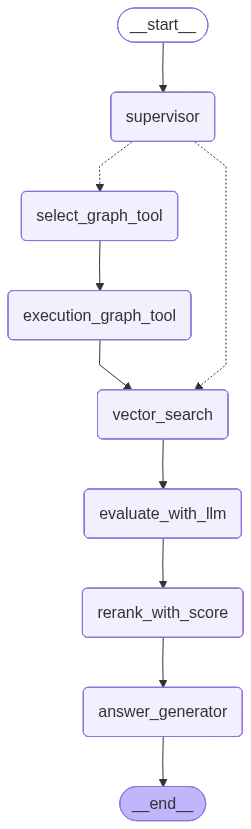

In [31]:
from IPython.display import Image, display

try:
    display(
        Image(
            hybrid_rag.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

# Hybrid RAG Test (테스트)

Hybrid RAG 시스템을 테스트하는 예제입니다.

## 테스트 시나리오

1. **GraphDB + VectorDB**: 구조적 정보가 포함된 질문
   - 예: "한겨레 언론사 뉴스 중에서 주택 관련 뉴스 찾아줘"
   - Graph Search와 Vector Search 모두 실행

2. **VectorDB만**: 의미 기반 검색이 필요한 일반적인 질문
   - 예: "박물관 관련 뉴스 조회해줘"
   - Vector Search만 실행

In [32]:
def run_hybrid_rag(question: str, verbose: bool = True):
    """
    Hybrid RAG 시스템을 실행하는 메인 함수
    
    이 함수는 전체 Hybrid RAG 워크플로우를 실행하고 결과를 반환합니다.
    
    실행 과정:
    1. 초기 상태 생성 (질문만 포함)
    2. 워크플로우 실행 (모든 노드가 순차적으로 실행됨)
    3. 결과 출력 및 반환
    
    Args:
        question: 사용자 질문
        verbose: 상세 정보 출력 여부 (기본값: True)
        
    Returns:
        dict: 최종 상태 (answer, relevant_docs 등 포함)
    """
    print("=" * 60)
    print(f"Hybrid RAG 실행")
    print("=" * 60)
    print(f"질문: {question}")
    print("-" * 60)
    
    # 초기 상태 설정: 질문만 포함된 상태로 시작
    initial_state = {
        "question": question
    }
    
    try:
        # 워크플로우 실행
        # config는 스레드 ID를 설정하여 대화 컨텍스트를 관리할 수 있게 함
        result = hybrid_rag.invoke(
            initial_state,
            config={"configurable": {"thread_id": "rag_thread"}}
        )
        
        # 상세 정보 출력
        if verbose:
            print("\n" + "=" * 60)
            print("실행 결과 요약")
            print("=" * 60)
            print(f"선택된 노드: {result.get('selected_node', 'N/A')}")
            print(f"벡터 검색 문서 수: {len(result.get('vector_docs', []))}")
            print(f"그래프 검색 문서 수: {len(result.get('graph_docs', []))}")
            print(f"재순위화된 문서 수: {len(result.get('reranked_docs', []))}")
            print(f"관련 문서 수: {len(result.get('relevant_docs', []))}")
            print("\n" + "=" * 60)
            print("최종 답변")
            print("=" * 60)
        
        print(result.get("answer", "답변을 생성할 수 없습니다."))
        
        return result
        
    except Exception as e:
        # 오류 발생 시 상세 정보 출력
        error_message = f"Hybrid RAG 실행 중 오류가 발생했습니다: {str(e)}"
        print(error_message)
        import traceback
        traceback.print_exc()

print("Hybrid RAG 실행 함수 구현 완료!")

Hybrid RAG 실행 함수 구현 완료!


## GraphDB + VectorDB 테스트

구조적 정보(언론사, 카테고리 등)가 포함된 질문으로 테스트합니다.
이 경우 Graph Search와 Vector Search가 모두 실행됩니다.

In [33]:
result1 = run_hybrid_rag("한겨레 언론사 뉴스 중에서 주택 관련 뉴스 찾아줘.")

Hybrid RAG 실행
질문: 한겨레 언론사 뉴스 중에서 주택 관련 뉴스 찾아줘.
------------------------------------------------------------
Supervisor 결정: graphdb - 질문에서 언론사(한겨레)가 명시되었기 때문에 graphdb를 선택합니다.
AI 에이전트가 요청을 분석 중...
1개의 도구를 사용합니다:
   - search_news_by_publisher: {'publisher_name': '한겨레', 'limit_no': 5}
search_news_by_publisher 실행 중... (인자: {'publisher_name': '한겨레', 'limit_no': 5})
GraphSearch: 0개의 문서를 검색했습니다.
VectorSearch: 3개의 문서를 검색했습니다.
Evaluate : 0개의 문서를 검색했습니다.

실행 결과 요약
선택된 노드: graphdb
벡터 검색 문서 수: 3
그래프 검색 문서 수: 0
재순위화된 문서 수: 0
관련 문서 수: 0

최종 답변
죄송하지만 현재 제 브라우징 기능이 비활성화되어 한겨레(Hankyoreh) 최신 기사 중 주택 관련 뉴스를 직접 찾아 목록으로 제공해 드리지는 못합니다. 대신 아래와 같이 직접 쉽게 찾는 방법을 구체적으로 안내해 드립니다.

가장 빠르게 찾는 방법
- 방법 A: 한겨레 공식 사이트 검색
  - 사이트: https://www.hani.co.kr
  - 검색 창에 키워드 입력 예시: 주택, 주택정책, 임대차, 전월세, 부동산, 집값 등
  - 결과 필터 설정: 기사/뉴스 탭으로 한정, 날짜 범위(최근 1개월, 3개월, 6개월, 1년 등) 설정
  - 주제별 기사 목록에서 관심 기사 클릭

- 방법 B: 구글 등 외부 검색으로 한겨레 기사만 좁혀 보기
  - 예시 검색어:
    - site:hani.co.kr 주택
    - site:hani.co.kr 부동산 주택
    - site:hani.co.kr 임대차
    - s

## VectorDB 테스트

의미 기반 검색이 필요한 일반적인 질문으로 테스트합니다.
이 경우 Vector Search만 실행됩니다.

In [34]:
result2 = run_hybrid_rag("박물관 관련 뉴스 조회해줘.")

Hybrid RAG 실행
질문: 박물관 관련 뉴스 조회해줘.
------------------------------------------------------------
Supervisor 결정: vectordb - 질문이 특정 출처나 엔티티 없이 자연어 기반의 의미적 검색을 필요로 합니다.
VectorSearch: 3개의 문서를 검색했습니다.
Evaluate : 0개의 문서를 검색했습니다.

실행 결과 요약
선택된 노드: vectordb
벡터 검색 문서 수: 3
그래프 검색 문서 수: 0
재순위화된 문서 수: 0
관련 문서 수: 0

최종 답변
실시간으로 뉴스를 직접 조회해 오지는 못하지만, 박물관 관련 최신 뉴스를 찾는 데 도움이 되는 방법과 신뢰할 만한 소스를 안내해 드릴 수 있습니다. 원하시는 방식으로 진행해 드리겠습니다.

오늘 바로 활용 가능한 조회 방법
- 국내 기사 확인
  - 포털 뉴스 검색: Naver News, Daum News, Google News에서 “박물관 전시”, “박물관 개관”, “박물관 휴관/재개관”, “박물관 소장품 보존” 등의 키워드를 최근 기간으로 필터링
  - 주요 매체 구독: 연합뉴스, 조선일보, 중앙일보, 한겨레, 경향신문, 동아일보, 한국경제, 매일경제 등에서 관련 기사 확인
- 국제 기사 확인
  - Reuters, Associated Press, BBC, The Guardian, The Art Newspaper 등의 국제 매체에서 “museum news” 계열 키워드로 확인
- 전문 소스 및 협회
  - ICOM(국제박물관협의회) 공식 발표나 뉴스, 한국박물관협회 소식
- 알림 설정
  - 네이버/구글 알림, 뉴스 앱의 실시간 알림 설정으로 최신 기사 자동 수신

중요 검색 키워드 예시
- 전시: “박물관 전시”, “새로운 박물관 전시”, “박물관 기획전”
- 개관/재개관: “박물관 개관”, “박물관 재개관”, “새 전시관 오픈”
- 소장품/보존: “박물관 소장품 보존”, “박물관 복원”, “유물 보존”
- 지역